## Inicialização 

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
tf.config.list_physical_devices('GPU')

TensorFlow: 2.7.0


[]

## Carregue os dados

O conjunto de dados é armazenado na pasta `/datasets/faces/`, onde você pode encontrar "
- A pasta `final_files` com 7,6k fotos "
- O arquivo `labels.csv` com rótulos, com duas colunas: `file_name` e `real_age` 

Dado que o número de arquivos de imagem é bastante alto, é aconselhável evitar a leitura de todos de uma vez, o que consumiria muito recursos computacionais. Recomendamos que você crie um gerador com o ImageDataGenerator. Este método foi explicado no Capítulo 3, Lição 7 deste curso.

O arquivo de rótulo pode ser carregado como um arquivo CSV normal.

In [3]:
DATA_DIR = '/datasets/faces/'
IMG_DIR = os.path.join(DATA_DIR, 'final_files')
LABELS_PATH = os.path.join(DATA_DIR, 'labels.csv')

labels = pd.read_csv(LABELS_PATH)

display(labels.head())
labels.info()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [4]:
print("Total de linhas:", labels.shape[0])
print("Colunas:", labels.columns.tolist())
print("\nNulos por coluna:\n", labels.isna().sum())
print("\nDuplicatas:", labels.duplicated().sum())
print("\nArquivos únicos:", labels['file_name'].nunique())

# checagem rápida do diretório de imagens
print("\nImagens no diretório:", len(os.listdir(IMG_DIR)))

Total de linhas: 7591
Colunas: ['file_name', 'real_age']

Nulos por coluna:
 file_name    0
real_age     0
dtype: int64

Duplicatas: 0

Arquivos únicos: 7591

Imagens no diretório: 7591


## EDA

In [5]:
display(labels.head())
print("Shape (linhas, colunas):", labels.shape)
print("Colunas:", labels.columns.tolist())

print("\nNulos por coluna:\n", labels.isna().sum())
print("\nDuplicatas (linhas):", labels.duplicated().sum())
print("\nArquivos únicos:", labels['file_name'].nunique())

# Checar se as imagens realmente existem no diretório
existing_files = set(os.listdir(IMG_DIR))
missing = (~labels['file_name'].isin(existing_files)).sum()
print("\nArquivos ausentes no diretório:", missing)

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


Shape (linhas, colunas): (7591, 2)
Colunas: ['file_name', 'real_age']

Nulos por coluna:
 file_name    0
real_age     0
dtype: int64

Duplicatas (linhas): 0

Arquivos únicos: 7591

Arquivos ausentes no diretório: 0


Idade mínima: 1
Idade máxima: 100
Média: 31.2
Mediana: 29.0


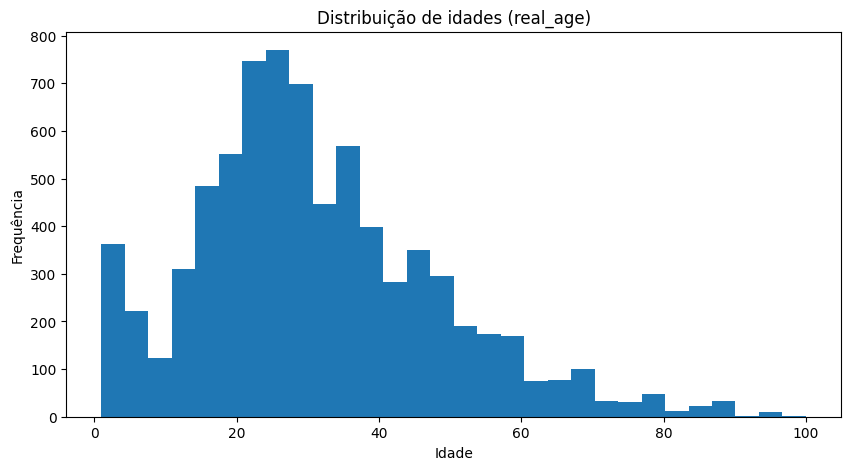

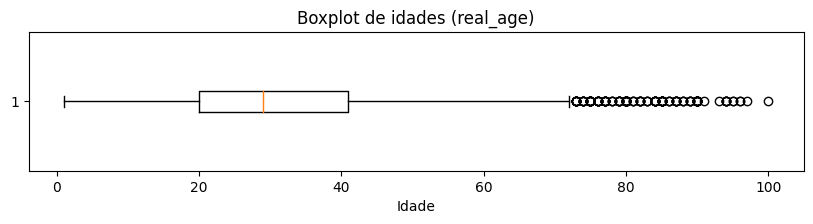

0-6       518
7-12      297
13-18     881
19-25    1419
26-35    1903
36-45    1130
46-60     997
60+       446
Name: real_age, dtype: int64

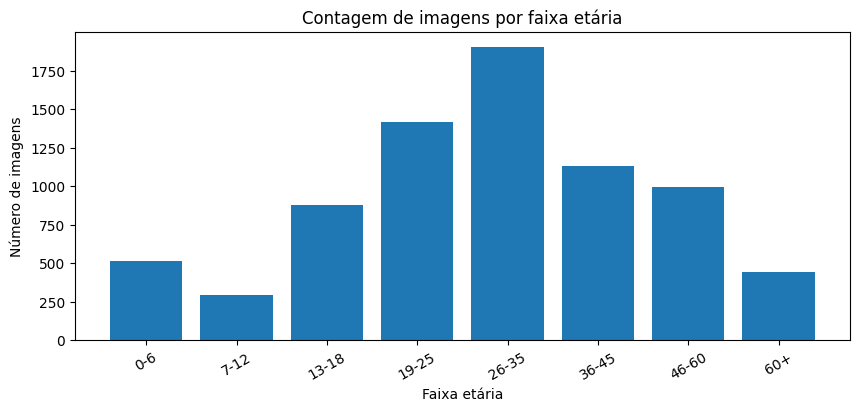

In [6]:
ages = labels['real_age']

print("Idade mínima:", ages.min())
print("Idade máxima:", ages.max())
print("Média:", round(ages.mean(), 2))
print("Mediana:", round(ages.median(), 2))

plt.figure(figsize=[10, 5])
plt.hist(ages, bins=30)
plt.title('Distribuição de idades (real_age)')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=[10, 1.8])
plt.boxplot(ages, vert=False)
plt.title('Boxplot de idades (real_age)')
plt.xlabel('Idade')
plt.show()

# Contagem por faixas (bins) para enxergar desbalanceamento
bins = [0, 6, 12, 18, 25, 35, 45, 60, 120]
bin_labels = ['0-6', '7-12', '13-18', '19-25', '26-35', '36-45', '46-60', '60+']
age_bins = pd.cut(ages, bins=bins, labels=bin_labels, include_lowest=True)
counts = age_bins.value_counts().sort_index()

display(counts)

plt.figure(figsize=[10, 4])
plt.bar(counts.index.astype(str), counts.values)
plt.title('Contagem de imagens por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Número de imagens')
plt.xticks(rotation=30)
plt.show()

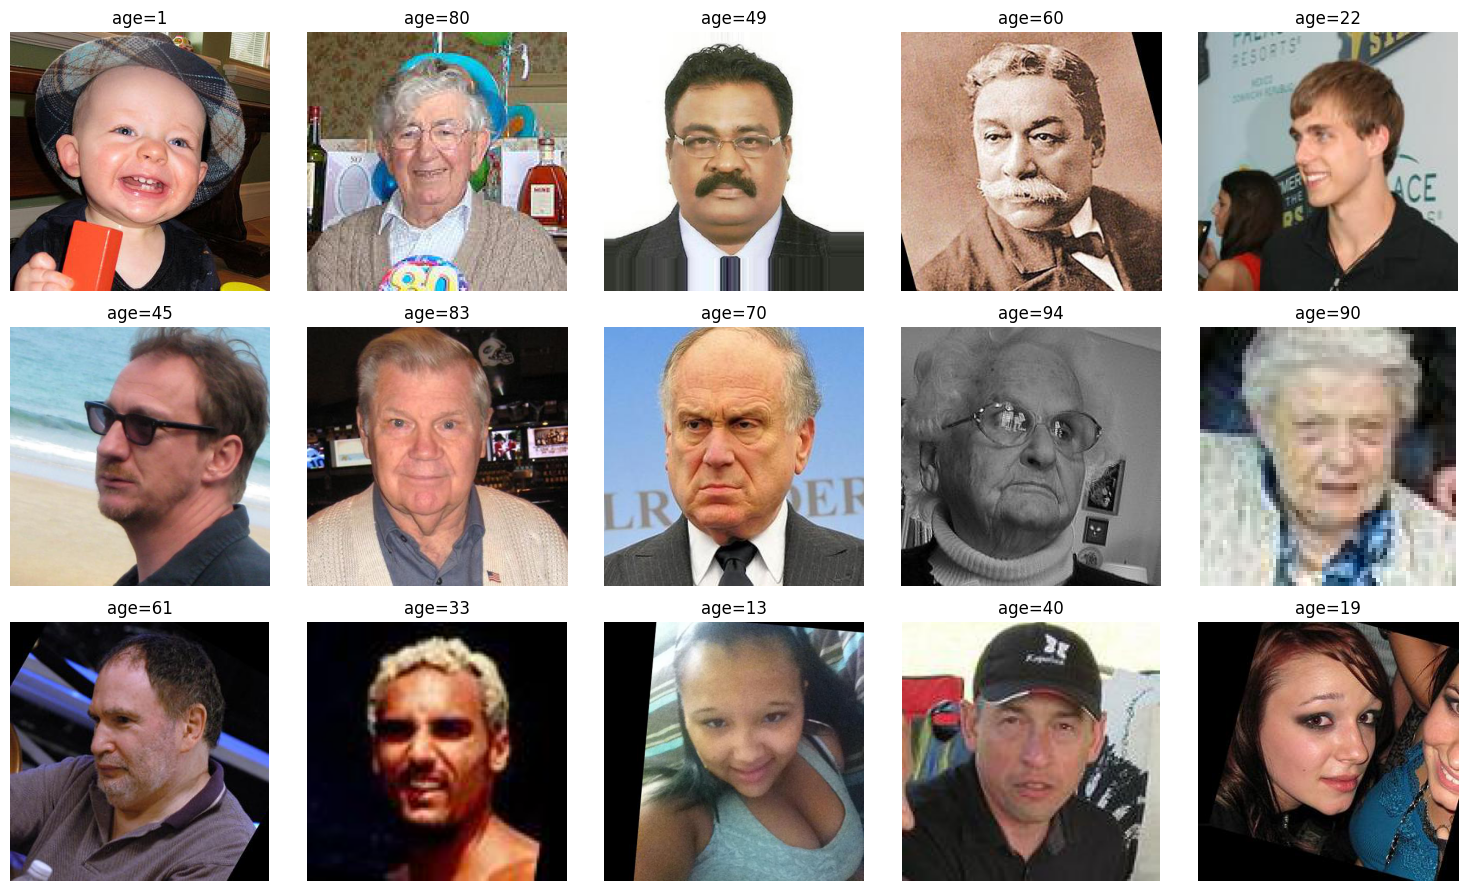

In [7]:
from PIL import Image

df = labels.copy()

# Criar 15 bins ao longo do intervalo de idades e pegar 1 imagem por bin
n_images = 15
age_edges = np.linspace(df['real_age'].min(), df['real_age'].max(), n_images + 1)
df['age_bin'] = pd.cut(df['real_age'], bins=age_edges, include_lowest=True)

sample_df = (
    df.groupby('age_bin', observed=True)
      .apply(lambda x: x.sample(1, random_state=12345) if len(x) > 0 else x)
      .reset_index(drop=True)
)

# Caso algum bin esteja vazio, completa com amostras aleatórias
if sample_df.shape[0] < n_images:
    remaining = n_images - sample_df.shape[0]
    extra = df.drop(sample_df.index, errors='ignore').sample(remaining, random_state=12345)
    sample_df = pd.concat([sample_df, extra], ignore_index=True)

sample_df = sample_df.sample(n_images, random_state=12345).reset_index(drop=True)

plt.figure(figsize=[15, 9])

for i in range(n_images):
    file_name = sample_df.loc[i, 'file_name']
    age = sample_df.loc[i, 'real_age']
    img_path = os.path.join(IMG_DIR, file_name)

    img = Image.open(img_path)
    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.title(f'age={age}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### Conclusões

## Modelagem 

Defina as funções necessárias para treinar seu modelo na plataforma GPU e construa um único script contendo todas elas junto com a seção de inicialização.

Para facilitar essa tarefa, você pode defini-las neste notebook e executar um código pronto na próxima seção para compor o script automaticamente.
As definições abaixo também serão verificadas pelos revisores do projeto, para que possam entender como você construiu o modelo.

In [8]:
import os
import math
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [9]:
def load_train(path):
    """
    Carrega a parte de treinamento do conjunto de dados a partir do caminho
    """
    labels_path = os.path.join(path, 'labels.csv')
    img_dir = os.path.join(path, 'final_files')

    df = pd.read_csv(labels_path)

    train_datagen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet.preprocess_input,
        validation_split=0.25,
        horizontal_flip=True,
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1
    )

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=df,
        directory=img_dir,
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )

    return train_gen_flow

In [10]:
def load_test(path):
    """
    Carrega a parte de validação/teste do conjunto de dados a partir do caminho
    """
    labels_path = os.path.join(path, 'labels.csv')
    img_dir = os.path.join(path, 'final_files')

    df = pd.read_csv(labels_path)

    test_datagen = ImageDataGenerator(
        preprocessing_function=tf.keras.applications.resnet.preprocess_input,
        validation_split=0.25
    )

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=df,
        directory=img_dir,
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345,
        shuffle=False
    )

    return test_gen_flow

In [14]:
def create_model(input_shape):
    """
    Define o modelo
    """
    backbone = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Fine-tuning leve: libera apenas as últimas camadas
    backbone.trainable = True
    for layer in backbone.layers[:-30]:
        layer.trainable = False

    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(1)  # saída linear para regressão
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss=tf.keras.losses.Huber(delta=5.0),
        metrics=['mae']
    )

    return model

In [12]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    """
    Treina o modelo de acordo com os parâmetros
    """
    if steps_per_epoch is None:
        steps_per_epoch = math.ceil(train_data.samples / train_data.batch_size)

    if validation_steps is None:
        validation_steps = math.ceil(test_data.samples / test_data.batch_size)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=2, verbose=1)
    ]

    model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=callbacks,
        verbose=1
    )

    return model

## Preparar o Script para a Execução na plataforma GPU

Dado que você definiu as funções necessárias, você pode compor um script para a plataforma GPU, baixá-lo através do menu "Arquivo|Abrir..." e carregá-lo posteriormente para execução na plataforma GPU.

Nota: O script também deve incluir a seção de inicialização. Um exemplo disso é mostrado abaixo.

In [13]:
# preparar um script para ser executado na plataforma GPU
init_str = """
import os
import math
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
print("GPU disponível:", len(tf.config.list_physical_devices('GPU')) > 0)
"""

run_str = """
DATA_DIR = '/datasets/faces/'

train_data = load_train(DATA_DIR)
test_data = load_test(DATA_DIR)

model = create_model(train_data.image_shape)
model.summary()

model = train_model(model, train_data, test_data, epochs=20)

print("\\nAvaliação final no conjunto de validação:")
loss, mae = model.evaluate(test_data, verbose=1)
print("loss (MSE):", loss)
print("MAE:", mae)
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    f.write(init_str)
    f.write("\n\n")
    for fn_name in [load_train, load_test, create_model, train_model]:
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write("\n\n")
    f.write(run_str)

print("Arquivo gerado: run_model_on_gpu.py")

Arquivo gerado: run_model_on_gpu.py


### Resultado

Avaliação final no conjunto de validação:
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - loss: 24.2924 - mae: 6.9283
loss (MSE): 24.93659782409668
MAE: 7.0751447677612305

## Conclusão

# Checklist

- [ ]  O notebook foi aberto 
- [ ]  O código está livre de erros 
- [ ]  As células com código foram organizadas por ordem de execução 
- [ ]  A análise exploratória dos dados foi realizada - [ ]  Os resultados da análise exploratória dos dados são apresentados no caderno final - [ ]  O valor EAM do modelo não é superior a 8 
- [ ]  O código de treinamento do modelo foi copiado para o notebook final 
- [ ]  A saída do treinamento do modelo foi copiada para o notebook final 
- [ ]  As conclusões foram fornecidas com base nos resultados do treinamento do modelo